In [1]:
import sys
from unittest.mock import Mock

# Creamos un modulo falso
mock_colab = Mock()

def mock_upload():
    print("Simulación: Deberias asegurarte de que el archivo .json ya esté en la carpeta local.")
    return {}

mock_colab.files.upload = mock_upload

# Lo inyectamos en los módulos del sistema (pero solo a google.colab, para no afectar a tensorflow)
sys.modules['google.colab'] = mock_colab

In [2]:
from google.colab import files

files.upload()

Simulación: Deberias asegurarte de que el archivo .json ya esté en la carpeta local.


{}

In [3]:
!pip install kaggle -q
import os


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Configuramos Kaggle para que busque el archivo kaggle.json en la carpeta actual
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()
print("Directorio de configuración de Kaggle establecido en:", os.environ['KAGGLE_CONFIG_DIR'])

Directorio de configuración de Kaggle establecido en: c:\Users\DIEGO\Desktop\Project-Grafica-Papa


In [5]:
# Descargar y descomprimir el dataset en una carpeta especifica ('dataset_papa')
!kaggle datasets download -d faysalmiah1721758/potato-dataset --unzip -p dataset_papa
print("Dataset descargado y extraído correctamente en la subcarpeta.")

Dataset URL: https://www.kaggle.com/datasets/faysalmiah1721758/potato-dataset
License(s): CC0-1.0

Dataset descargado y extraído correctamente en la subcarpeta.



  0%|          | 0.00/37.8M [00:00<?, ?B/s]
  3%|▎         | 1.00M/37.8M [00:01<00:39, 978kB/s]
  5%|▌         | 2.00M/37.8M [00:01<00:19, 1.90MB/s]
  8%|▊         | 3.00M/37.8M [00:01<00:12, 3.00MB/s]
 13%|█▎        | 5.00M/37.8M [00:01<00:06, 5.50MB/s]
 21%|██        | 8.00M/37.8M [00:01<00:03, 9.56MB/s]
 26%|██▋       | 10.0M/37.8M [00:01<00:02, 11.7MB/s]
 34%|███▍      | 13.0M/37.8M [00:01<00:01, 14.3MB/s]
 42%|████▏     | 16.0M/37.8M [00:02<00:01, 16.5MB/s]
 48%|████▊     | 18.0M/37.8M [00:02<00:01, 13.5MB/s]
 53%|█████▎    | 20.0M/37.8M [00:02<00:01, 13.9MB/s]
 61%|██████    | 23.0M/37.8M [00:02<00:00, 17.1MB/s]
 66%|██████▌   | 25.0M/37.8M [00:02<00:00, 16.6MB/s]
 74%|███████▍  | 28.0M/37.8M [00:02<00:00, 17.4MB/s]
 82%|████████▏ | 31.0M/37.8M [00:02<00:00, 19.1MB/s]
 87%|████████▋ | 33.0M/37.8M [00:03<00:00, 19.2MB/s]
 93%|█████████▎| 35.0M/37.8M [00:03<00:00, 19.5MB/s]
100%|██████████| 37.8M/37.8M [00:03<00:00, 20.5MB/s]
100%|██████████| 37.8M/37.8M [00:03<00:00, 12.0MB/s]


In [6]:
# Instala las librerías necesarias para procesar las imágenes y crear los modelos
!pip install tensorflow matplotlib -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Definir hiperparametros de infraestructura
BATCH_SIZE = 32
IMG_SIZE = (224, 224) # Tamaño estándar para arquitecturas como MobileNet o ResNet

# Establecemos la carpeta donde acabamos de descargar las imágenes
DATA_DIR = "dataset_papa"

# Revisamos si Kaggle extrajo las clases dentro de una subcarpeta adicional
subcarpetas = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
if len(subcarpetas) == 1:
    DATA_DIR = os.path.join(DATA_DIR, subcarpetas[0])

# Conteo de distribución (filtrando solo carpetas)
clases = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
for clase in clases:
    num_imgs = len(os.listdir(os.path.join(DATA_DIR, clase)))
    print(f"Clase '{clase}': {num_imgs} imágenes")

# Creación del pipeline de Entrenamiento (80%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Creación del pipeline de Validación (20%)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"Clases detectadas en el pipeline: {class_names}")

Clase 'Potato___Early_blight': 1000 imágenes
Clase 'Potato___healthy': 152 imágenes
Clase 'Potato___Late_blight': 1000 imágenes
Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Clases detectadas en el pipeline: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


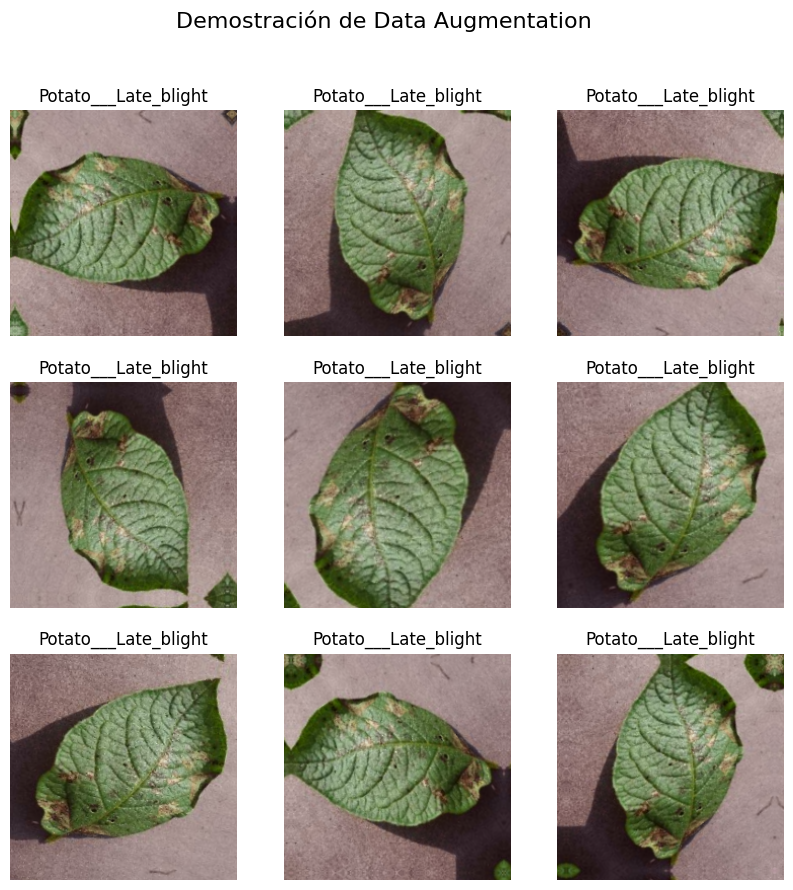

In [8]:
from tensorflow.keras import layers

# Definir la capa de aumento de datos secuencial
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2), # Rotación aleatoria del 20%
  layers.RandomZoom(0.1),
  layers.RandomContrast(0.1)  # Variación para simular distintas iluminaciones
])

# Visualizar el efecto del Data Augmentation para la presentación
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    # Tomar la primera imagen del batch
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Aplicar el aumento a la misma imagen
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255.0) # Normalizar para matplotlib
        plt.title(class_names[labels[0]])
        plt.axis("off")
plt.suptitle("Demostración de Data Augmentation", fontsize=16)
plt.show()

In [9]:
# AUTOTUNE delega a TensorFlow la gestión del tamaño del buffer en tiempo de ejecución
AUTOTUNE = tf.data.AUTOTUNE

# Aplicar las optimizaciones de I/O
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Pipelines de datos optimizados en memoria estática y asíncrona.")

Pipelines de datos optimizados en memoria estática y asíncrona.


### Segmentación con Watershed (Unidad 2)

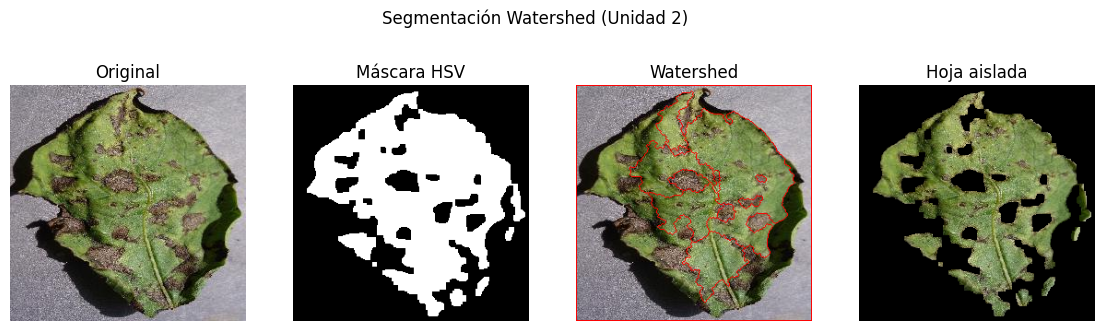

In [10]:
import cv2
import numpy as np
import glob

# Tomamos una muestra del dataset ya descargado
ruta = glob.glob(os.path.join(DATA_DIR, "Potato___Early_blight", "*"))[0]
img = cv2.imread(ruta)

# HSV + máscara: nos quedamos con el verde de la hoja e ignoramos el fondo
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
mascara = cv2.inRange(hsv, np.array([25, 40, 40]), np.array([95, 255, 255]))

kernel = np.ones((3, 3), np.uint8)
mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel, iterations=2)
mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=2)

# Marcadores para Watershed: fondo seguro, primer plano seguro y región desconocida
sure_bg = cv2.dilate(mascara, kernel, iterations=3)
dist = cv2.distanceTransform(mascara, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
markers = cv2.watershed(img, markers)

# Contornos en rojo y hoja aislada sobre fondo negro
contornos = img.copy()
contornos[markers == -1] = [0, 0, 255]
aislada = cv2.bitwise_and(img, img, mask=mascara)

# Mostrar etapas (cv2 trabaja en BGR, matplotlib en RGB)
etapas = [(img, "Original"), (mascara, "Máscara HSV"), (contornos, "Watershed"), (aislada, "Hoja aislada")]
plt.figure(figsize=(14, 4))
for i, (im, titulo) in enumerate(etapas):
    plt.subplot(1, 4, i + 1)
    plt.imshow(im, cmap="gray") if im.ndim == 2 else plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis("off")
plt.suptitle("Segmentación Watershed (Unidad 2)")
plt.show()

### Script de Entrenamiento 

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf

# 1. Cargar el modelo base preentrenado ResNet50
# include_top=False realizara que le quite la clasificación original (las 1000 clases de ImageNet: perro, gato, avión, auto, etc.)
# weights='imagenet' el modelo ya aprendio con millones de imágenes: bordes, formas, texturas, objetos y no entrenara desde cero
base_model = ResNet50(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Congela todas las capas del modelo base para que sus pesos no cambien durante el entrenamiento
base_model.trainable = False 

# 2. Construir la arquitectura
model = models.Sequential([
    data_augmentation, 
    
    # Lambda aplica una función 'preprocess_input' que alinea 
    # los colores de las fotos para que encajen matemáticamente con lo que ResNet espera
    layers.Lambda(preprocess_input), 
    
    # El cerebro convolucional
    base_model,
    
    # Convertimos los mapas de características 2D a un vector 1D
    layers.GlobalAveragePooling2D(),
    
    # Apagamos neuronas al azar al 30% (Dropout) para obligar a que la red no memorice las hojas de papas
    layers.Dropout(0.3),
    
    # La salida real: capa densa del tamaño de 'class_names' (3: saludable, temprana, tardía)
    # Softmax da como salida porcentajes del 0 al 1
    layers.Dense(len(class_names), activation='softmax') 
])

# 3. Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Aplicamos el optimizador Adam
    loss='sparse_categorical_crossentropy', # Función de pérdida (error)
    metrics=['accuracy'] # Precisión
)

# 4. Configurar Early Stopping (Script Avanzado)
# Si en 3 épocas el 'val_loss' (error en nuevos datos) no baja, detiene todo y evita un sobreajuste
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# 5. Ejecutar el entrenamiento
print("Iniciando entrenamiento con arquitectura ResNet50...")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15, # Limite maximo de rondas, pero tomamos en cuenta que Early Stopping detendrá antes si no hay mejora
    callbacks=[early_stopping]
)

# 6. Guardar el modelo
# .h5 es el formato en que TensorFlow guarda todo el bloque neuronal y pesos
model.save('modelo_papas_resnet50.h5')
print("Modelo ResNet guardado exitosamente.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Iniciando entrenamiento con arquitectura ResNet50...
Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5319 - loss: 0.9528 - val_accuracy: 0.7651 - val_loss: 0.6293
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.6928 - loss: 0.6583 - val_accuracy: 0.8628 - val_loss: 0.4567
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8014 - loss: 0.5011 - val_accuracy: 0.8814 - val_loss: 0.3638
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8566 - loss: 0.4041 - val_accuracy: 0.9000 - val_loss: 0.3034
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8682 - loss: 0.3537 - val_accuracy: 0.9116 - val_loss: 0.2580
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8995 - loss: 0.2855 - val_accuracy: 0.9302 - val_loss: 0.2310
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9170 - loss: 0.2561 - val_accuracy: 0.9326 - val_loss: 0.2094
Epoch 8/15
54

Modelo ResNet guardado exitosamente.
